In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
rootdir = '/Users/thepoetoftwilight/Documents/CUBS/Data/PG1522+101/'

In [3]:
plt.style.use('/Users/thepoetoftwilight/Documents/CUBS/Code/science.mplstyle')

Species names

In [4]:
O_list = ['OI', 'OII', 'OIII', 'OIV', 'OV', 'OVI', 'OVII', 'OVIII', 'OIX']

O_species = [r'$\mathrm{O}^0$', r'$\mathrm{O}^+$', r'$\mathrm{O}^{2+}$', r'$\mathrm{O}^{3+}$',
            r'$\mathrm{O}^{4+}$', r'$\mathrm{O}^{5+}$', r'$\mathrm{O}^{6+}$',
            r'$\mathrm{O}^{7+}$', r'$\mathrm{O}^{8+}$']

In [5]:
C_list = ['CI', 'CII', 'CIII', 'CIV', 'CV', 'CVI', 'CVII']

C_species = [r'$\mathrm{C}^0$', r'$\mathrm{C}^+$', r'$\mathrm{C}^{2+}$', r'$\mathrm{C}^{3+}$',
            r'$\mathrm{C}^{4+}$', r'$\mathrm{C}^{5+}$', r'$\mathrm{C}^{6+}$', r'$\mathrm{C}^{6+}$'] 

# CIE

Load CLOUDY grid

In [6]:
T_grid_CIE = 10**np.arange(4, 7.02, 0.02)

In [10]:
X_dict_CIE = {k:np.zeros(len(T_grid_CIE)) for k in O_list}

f = open(rootdir+'cloudy_grids/non_eqm_models/CI/CIE/coll t6.oxy', 'r')
L = f.readlines()
f.close()

for s in O_list:
    for i in range(1, len(T_grid_CIE)):
        X_dict_CIE[s][i] = float(L[i].split('\t')[O_list.index(s)+1])

In [11]:
colors_list = ['black', 'black', 'dodgerblue', 'dodgerblue', 
               'forestgreen', 'forestgreen', 'firebrick', 'firebrick', 
               'tan']
ls_list = ['-', '--', '-', '--', '-', '--', '-', '--', '-', '--', '-']

(0.0012589254117941675, 1.9952623149688795)

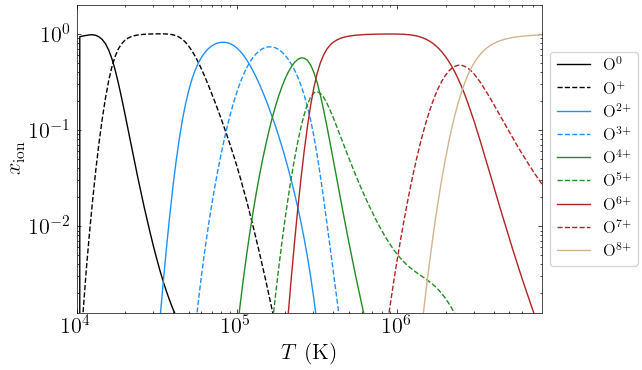

In [12]:
fig, ax = plt.subplots(1, figsize=(6,4))

for i in range(len(O_list)):
    
    s = O_list[i]
    
    ax.plot(T_grid_CIE, X_dict_CIE[s], 
            color=colors_list[i], 
            linestyle = ls_list[i], label=O_species[i])
    
    
box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width, box.height])

# Put a legend to the right of the current axis
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

ax.set_xlabel(r'$T \ (\mathrm{K})$')
ax.set_ylabel(r'$x_\mathrm{ion}$')
    
ax.set_xscale('log')
ax.set_yscale('log')
    
ax.set_xlim(10**4,10**6.9)
ax.set_ylim(10**-2.9, 10**0.3)

Load GS07

In [13]:
gs07_table_CIE = np.loadtxt(rootdir+'gs07_grids/table2a.dat')

In [14]:
T_grid_gs07_CIE = gs07_table_CIE[:,0]

In [15]:
X_dict_gs07_CIE = {k:np.zeros(len(T_grid_gs07_CIE)) for k in O_list}

for i in range(len(O_list)):
    s = O_list[i]
    X_dict_gs07_CIE[s] = gs07_table_CIE[:,21+i]

Compare ion fractions

In [16]:
colors_list = ['black', 'black', 'dodgerblue', 'dodgerblue', 
               'forestgreen', 'forestgreen', 'firebrick', 'firebrick', 
               'tan']
ls_list = ['-', '--', '-', '--', '-', '--', '-', '--', '-', '--', '-']

In [60]:
x_list = [1.3e+4, 3e+4, 7e+4, 1.3e+5, 2.2e+5, 4.6e+5, 8e+5, 2e+6, 3e+6]
y_list = [1.1e0, 1.1e+0, 9.2e-1, 8e-1, 6e-1, 1e-1, 1.1e+0, 5e-1, 9.8e-1]

(0.0012589254117941675, 1.9952623149688795)

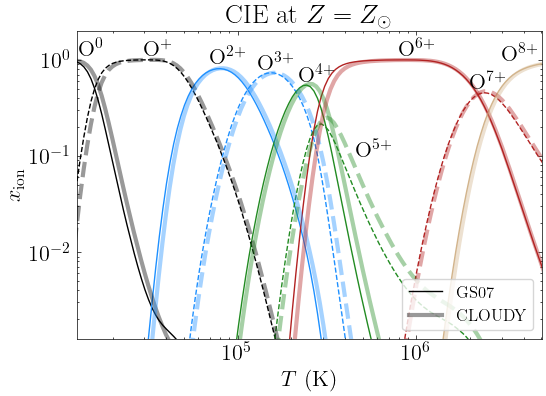

In [61]:
fig, ax = plt.subplots(1, figsize=(6,4))

for i in range(len(O_list)):
    
    s = O_list[i]
    
    if i==0:
        l = 'GS07'
    else:
        l = None
    
    ax.plot(T_grid_gs07_CIE, X_dict_gs07_CIE[s], 
            color=colors_list[i], 
            linestyle = ls_list[i], label=l)
    
    ax.text(x_list[i], y_list[i], O_species[i])
    
for i in range(len(O_list)):
    
    s = O_list[i]
    
    if i==0:
        l = 'CLOUDY'
    else:
        l = None
    
    ax.plot(T_grid_CIE, X_dict_CIE[s], 
            color=colors_list[i], 
            linestyle = ls_list[i], lw=3, alpha=.4, label=l)    
    
#box = ax.get_position()
#ax.set_position([box.x0, box.y0, box.width, box.height])

# Put a legend to the right of the current axis
ax.legend(loc='lower right')#, bbox_to_anchor=(1, 0.5))

ax.set_xlabel(r'$T \ (\mathrm{K})$')
ax.set_ylabel(r'$x_\mathrm{ion}$')
    
ax.set_xscale('log')
ax.set_yscale('log')

ax.set_title(r'CIE at $Z=Z_\odot$')
    
ax.set_xlim(10**4.1,10**6.7)
ax.set_ylim(10**-2.9, 10**0.3)

(0.0012589254117941675, 1.5848931924611136)

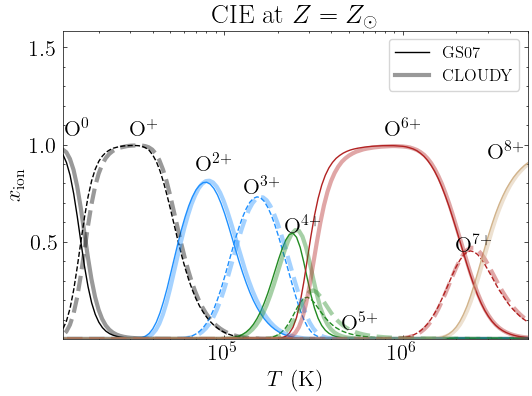

In [67]:
fig, ax = plt.subplots(1, figsize=(6,4))

for i in range(len(O_list)):
    
    s = O_list[i]
    
    if i==0:
        l = 'GS07'
    else:
        l = None
    
    ax.plot(T_grid_gs07_CIE, X_dict_gs07_CIE[s], 
            color=colors_list[i], 
            linestyle = ls_list[i], label=l)
    
    ax.text(x_list[i], y_list[i]-0.05, O_species[i])
    
for i in range(len(O_list)):
    
    s = O_list[i]
    
    if i==0:
        l = 'CLOUDY'
    else:
        l = None
    
    ax.plot(T_grid_CIE, X_dict_CIE[s], 
            color=colors_list[i], 
            linestyle = ls_list[i], lw=3, alpha=.4, label=l)    
    
#box = ax.get_position()
#ax.set_position([box.x0, box.y0, box.width, box.height])

# Put a legend to the right of the current axis
ax.legend(loc='upper right')#, bbox_to_anchor=(1, 0.5))

ax.set_xlabel(r'$T \ (\mathrm{K})$')
ax.set_ylabel(r'$x_\mathrm{ion}$')
    
ax.set_xscale('log')
#ax.set_yscale('log')

ax.set_title(r'CIE at $Z=Z_\odot$')
    
ax.set_xlim(10**4.1,10**6.7)
ax.set_ylim(10**-2.9, 10**0.2)

# Non-equilibrium collisional ionization

Read in temperature grid

In [6]:
f = open(rootdir+'Non-equilibrium/hazy1/cp-cool-1keV.tim', 'r')
L = f.readlines()
f.close()

In [7]:
T_grid = np.array([L[i].split('\t')[4] for i in range(1, len(L))], dtype=float)

Read in ion fractions

In [8]:
X_Z_0 = {k:np.zeros(len(T_grid)) for k in O_list}

In [9]:
f = open(rootdir+'Non-equilibrium/hazy1/cp-cool-1keV.oxy', 'r')
L = f.readlines()
f.close()

for s in O_list:
    for i in range(1,len(T_grid)):
        X_Z_0[s][i] = float(L[i].split('\t')[O_list.index(s)+1])

Plot ion fractions

In [10]:
colors_list = ['black', 'black', 'dodgerblue', 'dodgerblue', 
               'forestgreen', 'forestgreen', 'firebrick', 'firebrick', 
               'tan']
ls_list = ['-', '--', '-', '--', '-', '--', '-', '--', '-', '--', '-']

(0.0012589254117941675, 1.9952623149688795)

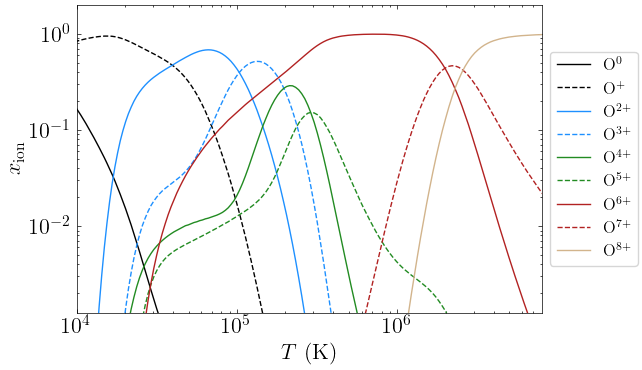

In [11]:
fig, ax = plt.subplots(1, figsize=(6,4))

for i in range(len(O_list)):
    
    s = O_list[i]
    
    ax.plot(T_grid, X_Z_0[s], 
            color=colors_list[i], 
            linestyle = ls_list[i], label=O_species[i])
    
    
box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width, box.height])

# Put a legend to the right of the current axis
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

ax.set_xlabel(r'$T \ (\mathrm{K})$')
ax.set_ylabel(r'$x_\mathrm{ion}$')
    
ax.set_xscale('log')
ax.set_yscale('log')
    
ax.set_xlim(10**4,10**6.9)
ax.set_ylim(10**-2.9, 10**0.3)

Load in the ion fractions for Gnat and Sternberg 2007

In [12]:
gs07_table = np.loadtxt(rootdir+'gs07_grids/table2c.dat')

In [13]:
T_grid_gs07 = gs07_table[:,0]

In [14]:
X_Z_0_gs07 = {k:np.zeros(len(T_grid_gs07)) for k in O_list}

for i in range(len(O_list)):
    s = O_list[i]
    X_Z_0_gs07[s] = gs07_table[:,21+i]

In [15]:
#X_Z_0_gs07

In [16]:
x_list = [1.1e+4, 1.5e+4, 6e+4, 1.2e+5, 2.2e+5, 4e+5, 8e+5, 1.1e+6, 3e+6]
y_list = [2e-1, 1.1e+0, 8.5e-1, 6.7e-1, 3e-1, 1e-1, 1.1e+0, 3.5e-1, 1e+0]

(0.0012589254117941675, 1.9952623149688795)

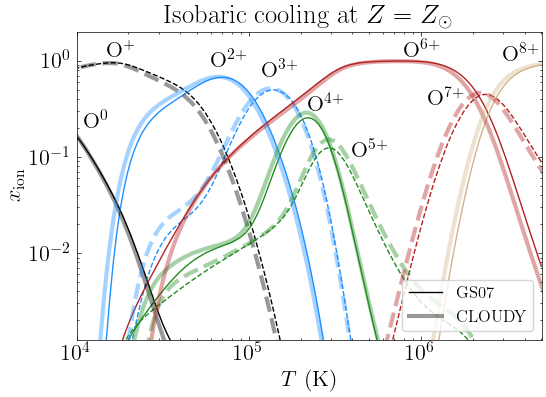

In [17]:
fig, ax = plt.subplots(1, figsize=(6,4))

for i in range(len(O_list)):
    
    s = O_list[i]
    
    if i==0:
        l = 'GS07'
    else:
        l = None
    
    ax.plot(T_grid_gs07, X_Z_0_gs07[s], 
            color=colors_list[i], 
            linestyle = ls_list[i], label=l)
    
    ax.text(x_list[i], y_list[i], O_species[i])
    
for i in range(len(O_list)):
    
    s = O_list[i]
    
    if i==0:
        l = 'CLOUDY'
    else:
        l = None
    
    ax.plot(T_grid, X_Z_0[s], 
            color=colors_list[i], 
            linestyle = ls_list[i], lw=3, alpha=.4, label=l)    
    
#box = ax.get_position()
#ax.set_position([box.x0, box.y0, box.width, box.height])

# Put a legend to the right of the current axis
ax.legend(loc='lower right')#, bbox_to_anchor=(1, 0.5))

ax.set_xlabel(r'$T \ (\mathrm{K})$')
ax.set_ylabel(r'$x_\mathrm{ion}$')
    
ax.set_xscale('log')
ax.set_yscale('log')

ax.set_title(r'Isobaric cooling at $Z=Z_\odot$')
    
ax.set_xlim(10**4,10**6.7)
ax.set_ylim(10**-2.9, 10**0.3)

# Non-equilibrium ion fractions - HM12

Read in temperature grid

In [18]:
f = open(rootdir+'Non-equilibrium/ebr_frac/hm12/cd-cool-1keV.tim', 'r')
L = f.readlines()
f.close()

In [19]:
T_grid = np.array([L[i].split('\t')[4] for i in range(1, len(L))], dtype=float)

Read in ion fractions

In [20]:
X_Z_0 = {k:np.zeros(len(T_grid)) for k in O_list}

In [21]:
f = open(rootdir+'Non-equilibrium/ebr_frac/hm12/cd-cool-1keV.oxy', 'r')
L = f.readlines()
f.close()

for s in O_list:
    for i in range(1,len(T_grid)):
        X_Z_0[s][i] = float(L[i].split('\t')[O_list.index(s)+1])

Plot ion fractions

In [22]:
colors_list = ['black', 'black', 'dodgerblue', 'dodgerblue', 
               'forestgreen', 'forestgreen', 'firebrick', 'firebrick', 
               'tan']
ls_list = ['-', '--', '-', '--', '-', '--', '-', '--', '-', '--', '-']

(0.0012589254117941675, 1.9952623149688795)

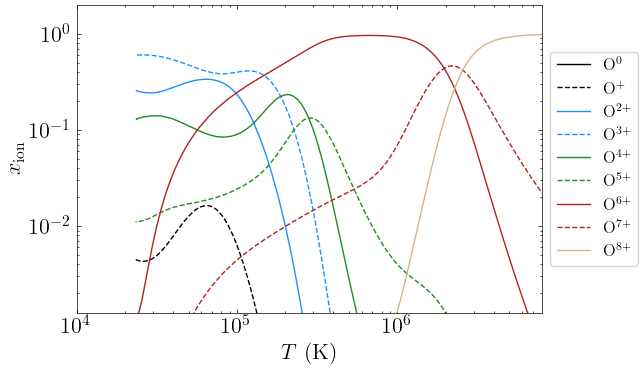

In [23]:
fig, ax = plt.subplots(1, figsize=(6,4))

for i in range(len(O_list)):
    
    s = O_list[i]
    
    ax.plot(T_grid, X_Z_0[s], 
            color=colors_list[i], 
            linestyle = ls_list[i], label=O_species[i])
    
    
box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width, box.height])

# Put a legend to the right of the current axis
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

ax.set_xlabel(r'$T \ (\mathrm{K})$')
ax.set_ylabel(r'$x_\mathrm{ion}$')
    
ax.set_xscale('log')
ax.set_yscale('log')
    
ax.set_xlim(10**4,10**6.9)
ax.set_ylim(10**-2.9, 10**0.3)

Load in the ion fractions for Gnat and 2017

In [24]:
g17_table = np.loadtxt(rootdir+'g17_grids/table11_sub.dat')

In [25]:
T_grid_g17 = g17_table[:,0]

In [26]:
X_Z_0_g17 = {k:np.zeros(len(T_grid_g17)) for k in O_list}

for i in range(len(O_list)):
    s = O_list[i]
    X_Z_0_g17[s] = g17_table[:,21+i]

In [27]:
#X_Z_0_g17

In [28]:
x_list = [1.1e+4, 9e+4, 3e+4, 9e+4, 2e+5, 4e+5, 8e+5, 1.1e+6, 3e+6]
y_list = [2e-6, 1e-2, 3e-1, 5e-1, 3e-1, 1e-1, 1.1e+0, 3.5e-1, 1e+0]

(0.0012589254117941675, 1.9952623149688795)

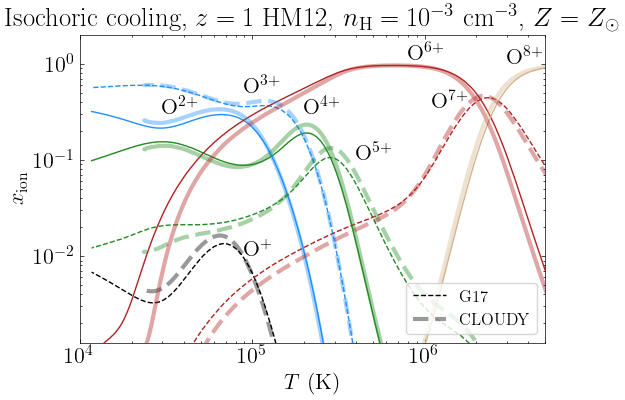

In [29]:
fig, ax = plt.subplots(1, figsize=(6,4))

for i in range(1,len(O_list)):
    
    s = O_list[i]
    
    if i==1:
        l = 'G17'
    else:
        l = None
    
    ax.plot(T_grid_g17, X_Z_0_g17[s], 
            color=colors_list[i], 
            linestyle = ls_list[i], label=l)
    
    ax.text(x_list[i], y_list[i], O_species[i])
    
for i in range(1,len(O_list)):
    
    s = O_list[i]
    
    if i==1:
        l = 'CLOUDY'
    else:
        l = None
    
    ax.plot(T_grid, X_Z_0[s], 
            color=colors_list[i], 
            linestyle = ls_list[i], lw=3, alpha=.4, label=l)    
    
#box = ax.get_position()
#ax.set_position([box.x0, box.y0, box.width, box.height])

# Put a legend to the right of the current axis
ax.legend(loc='lower right')#, bbox_to_anchor=(1, 0.5))

ax.set_xlabel(r'$T \ (\mathrm{K})$')
ax.set_ylabel(r'$x_\mathrm{ion}$')
    
ax.set_xscale('log')
ax.set_yscale('log')

ax.set_title(r'Isochoric cooling, $z=1$ HM12, $n_\mathrm{H}=10^{-3} \ \mathrm{cm}^{-3}$, $Z=Z_\odot$')
    
ax.set_xlim(10**4,10**6.7)
ax.set_ylim(10**-2.9, 10**0.3)

# Non-equilibrium ion fractions - FG20 vs. HM12

Read in temperature grid

In [30]:
f = open(rootdir+'Non-equilibrium/ebr_frac/fg20/cd-cool-1keV.tim', 'r')
L = f.readlines()
f.close()

In [31]:
T_grid_fg20 = np.array([L[i].split('\t')[4] for i in range(1, len(L))], dtype=float)

Read in ion fractions

In [32]:
X_Z_0_fg20 = {k:np.zeros(len(T_grid_fg20)) for k in O_list}

In [33]:
f = open(rootdir+'Non-equilibrium/ebr_frac/fg20/cd-cool-1keV.oxy', 'r')
L = f.readlines()
f.close()

for s in O_list:
    for i in range(1,len(T_grid_fg20)):
        X_Z_0_fg20[s][i] = float(L[i].split('\t')[O_list.index(s)+1])

Plot ion fractions

In [34]:
x_list = [1.5e+4, 9e+4, 2.5e+4, 9e+4, 2e+5, 4e+5, 8e+5, 1.1e+6, 3e+6]
y_list = [2e-6, 1e-2, 3e-1, 5e-1, 3e-1, 1e-1, 1.1e+0, 3.5e-1, 1e+0]

(0.0012589254117941675, 1.2589254117941673)

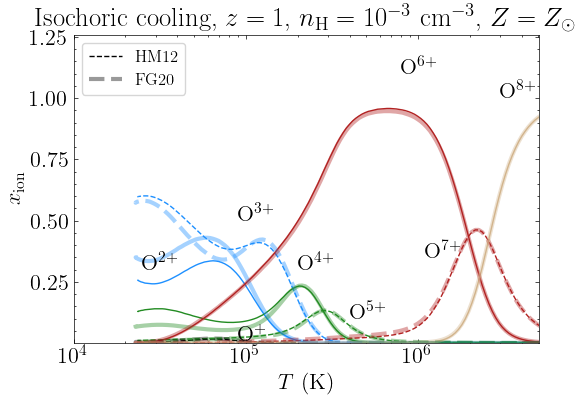

In [35]:
fig, ax = plt.subplots(1, figsize=(6,4))

for i in range(1,len(O_list)):
    
    s = O_list[i]
    
    if i==1:
        l = 'HM12'
    else:
        l = None
    
    ax.plot(T_grid, X_Z_0[s], 
            color=colors_list[i], 
            linestyle = ls_list[i], label=l)
    
    ax.text(x_list[i], y_list[i], O_species[i])
    
for i in range(1,len(O_list)):
    
    s = O_list[i]
    
    if i==1:
        l = 'FG20'
    else:
        l = None
    
    ax.plot(T_grid_fg20, X_Z_0_fg20[s], 
            color=colors_list[i], 
            linestyle = ls_list[i], lw=3, alpha=.4, label=l)    
    
#box = ax.get_position()
#ax.set_position([box.x0, box.y0, box.width, box.height])

# Put a legend to the right of the current axis
ax.legend(loc='upper left')#, bbox_to_anchor=(1, 0.5))

ax.set_xlabel(r'$T \ (\mathrm{K})$')
ax.set_ylabel(r'$x_\mathrm{ion}$')
    
ax.set_xscale('log')
#ax.set_yscale('log')

ax.set_title(r'Isochoric cooling, $z=1$, $n_\mathrm{H}=10^{-3} \ \mathrm{cm}^{-3}$, $Z=Z_\odot$')
    
ax.set_xlim(10**4,10**6.7)
ax.set_ylim(10**-2.9, 10**0.1)